# Moore’s Law Linear Regression

You are given a dataset describing Moore’s Law, stored in the file **`./datat/moore.csv`**.  
Each record contains information about the **year**, **transistor count**, and other details for integrated circuits.  
Your task is to implement a simple **linear regression model** in **PyTorch** to estimate the rate at which transistor counts have historically increased.

---
---

### Expected Output

- Scatter plots of data before and after preprocessing  
- A decreasing loss curve across epochs  
- A final fitted regression line  
- Calculated doubling‑time value (approximately **2 years** for real Moore’s Law data)


#### Your answer:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
import os
import re
from IPython.display import display

In [ ]:
# Read the file as tab-separated, clean transistor count, and re-run the regression analysis.
CSV_PATH = "moore.csv"
df_raw = pd.read_csv(CSV_PATH, sep='\t', header=None, engine='python', dtype=str, keep_default_na=False)


In [6]:
# Inspect columns count and sample rows
print("Shape:", df_raw.shape)
print("First 8 rows (raw):")
display(df_raw.head(8))

Shape: (102, 6)
First 8 rows (raw):


,0,1,2,3,4,5
0,Intel 4004,"2,300",1971,Intel,"10,000 nm",12 mm²
1,Intel 8008,"3,500",1972,Intel,"10,000 nm",14 mm²
2,Intel 8080,"4,500",1974,Intel,"6,000 nm",20 mm²
3,Motorola 6800,"4,100",1974,Motorola,"6,000 nm",16 mm²
4,RCA 1802,"5,000",1974,RCA,"5,000 nm",27 mm²
5,TMS 1000,"8,000",1974[7],Texas Instruments,"8,000 nm",
6,MOS Technology 6502,"3,510[8]",1975,MOS Technology,"8,000 nm",21 mm²
7,Intel 8085,"6,500",1976,Intel,"3,000 nm",20 mm²


In [7]:
# Heuristic: assign columns
# From inspection, columns likely are: [name, transistor_count, year, manufacturer, node, die_area]
# But some lines may be missing trailing fields. We'll create column names and handle missing values.
col_names = ['name', 'transistor_count', 'year', 'manufacturer', 'node', 'die_area']
# If df_raw has more than 6 columns, join extras into the last column
if df_raw.shape[1] > len(col_names):
    # Merge extra columns into last column
    extras = df_raw.columns[len(col_names)-1:]
    df_raw[col_names[-1]] = df_raw[extras].astype(str).agg(' '.join, axis=1)
    df_raw = df_raw.iloc[:, :len(col_names)]
    df_raw.columns = col_names
else:
    df_raw.columns = col_names[:df_raw.shape[1]]
    # If fewer columns, add missing as empty
    for c in col_names[df_raw.shape[1]:]:
        df_raw[c] = ""

In [8]:
# Clean transistor_count: remove references like [22], remove commas, trim spaces, handle ranges or approximations
def clean_count(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    # remove bracketed references
    s = re.sub(r'\[.*?\]', '', s)
    # remove non-digit, non-comma, non-dot, non-minus characters
    s = re.sub(r'[^\d\.,-]', '', s)
    # remove commas used as thousands separators
    s = s.replace(',', '')
    # handle empty
    if s == "":
        return np.nan
    try:
        return float(s)
    except:
        return np.nan


In [9]:
df = df_raw.copy()
df['transistor_count_raw'] = df['transistor_count']
df['transistor_count_clean'] = df['transistor_count'].apply(clean_count)

In [10]:
# Clean year similarly
def clean_year(x):
    s = str(x)
    s = re.sub(r'\[.*?\]', '', s)
    s = re.sub(r'[^\d\-]', '', s)
    if s == "":
        return np.nan
    # if range like 1974-1975, take first
    if '-' in s:
        s = s.split('-')[0]
    try:
        return int(s)
    except:
        return np.nan

df['year_clean'] = df['year'].apply(clean_year)

In [16]:
# Drop rows without year or transistor count
df2 = df.dropna(subset=['year_clean', 'transistor_count_clean']).copy()
df2['year_clean'] = df2['year_clean'].astype(int)
df2['transistor_count_clean'] = df2['transistor_count_clean'].astype(float)

# Display the first 30 rows using standard Pandas
df2_to_show = df2[['name', 'transistor_count_raw', 'transistor_count_clean', 'year_clean', 'manufacturer', 'node']].head(30)

# Option 1: Jupyter notebook display
from IPython.display import display
display(df2_to_show)

# Option 2: If running in a script or console
print(df2_to_show)

,name,transistor_count_raw,transistor_count_clean,year_clean,manufacturer,node
0,Intel 4004,"2,300",2300.0,1971,Intel,"10,000 nm"
1,Intel 8008,"3,500",3500.0,1972,Intel,"10,000 nm"
2,Intel 8080,"4,500",4500.0,1974,Intel,"6,000 nm"
3,Motorola 6800,"4,100",4100.0,1974,Motorola,"6,000 nm"
4,RCA 1802,"5,000",5000.0,1974,RCA,"5,000 nm"
5,TMS 1000,"8,000",8000.0,1974,Texas Instruments,"8,000 nm"
6,MOS Technology 6502,"3,510[8]",3510.0,1975,MOS Technology,"8,000 nm"
7,Intel 8085,"6,500",6500.0,1976,Intel,"3,000 nm"
8,Zilog Z80,"8,500",8500.0,1976,Zilog,"4,000 nm"
9,Intel 8086,"29,000",29000.0,1978,Intel,"3,000 nm"


                                      name transistor_count_raw  \
0                               Intel 4004                2,300   
1                               Intel 8008                3,500   
2                               Intel 8080                4,500   
3                            Motorola 6800                4,100   
4                                 RCA 1802                5,000   
5                                 TMS 1000                8,000   
6                      MOS Technology 6502             3,510[8]   
7                               Intel 8085                6,500   
8                                Zilog Z80                8,500   
9                               Intel 8086               29,000   
10                           Motorola 6809                9,000   
11                              Intel 8088               29,000   
12                          Motorola 68000               68,000   
13                               WDC 65C02            11,500[9

In [18]:
# Now prepare arrays for modeling
years = df2['year_clean'].values.astype(float)
counts = df2['transistor_count_clean'].values.astype(float)


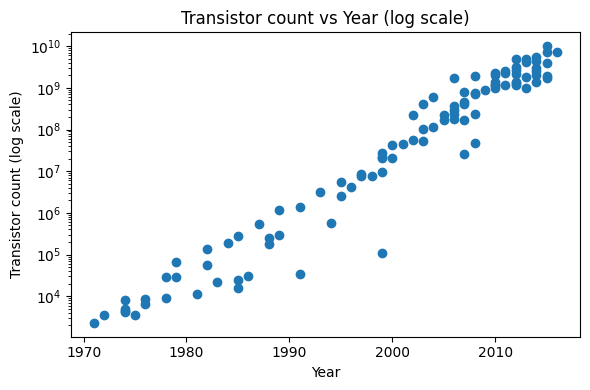

In [26]:
# Basic plots: raw count vs year (log scale)
fig1, ax1 = plt.subplots(figsize=(6,4))
ax1.scatter(years, counts)
ax1.set_yscale('log')
ax1.set_xlabel("Year")
ax1.set_ylabel("Transistor count (log scale)")
ax1.set_title("Transistor count vs Year (log scale)")
fig1_path = "moore_count_vs_year_log.png"
fig1.tight_layout()
fig1.savefig(fig1_path)

In [27]:
# Transform to log2 scale for linear modeling
log2_counts = np.log2(counts)
X = years.reshape(-1,1).astype(np.float32)
y = log2_counts.reshape(-1,1).astype(np.float32)

In [28]:
# Convert to torch tensors
X_t = torch.from_numpy(X)
y_t = torch.from_numpy(y)

In [29]:
# Normalize X for better conditioning
X_mean = X_t.mean(dim=0)
X_std = X_t.std(dim=0)
Xn = (X_t - X_mean) / X_std


In [30]:
# Build a simple linear model: y = a * (year_norm) + b
model = nn.Linear(1, 1, bias=True)

In [31]:
# Loss and optimizer
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.05)

In [32]:
# Training loop
n_epochs = 2000
loss_history = []
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    preds = model(Xn)
    loss = loss_fn(preds, y_t)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    if epoch == 1000:
        for g in optimizer.param_groups:
            g['lr'] = 0.01

In [33]:
# Extract parameters: convert slope back to per-year slope
with torch.no_grad():
    w = model.weight.item()
    b = model.bias.item()
slope_per_year = w / X_std.item()
intercept = b - w * (X_mean.item() / X_std.item())

In [34]:
# Predictions and R^2
y_pred = (model(Xn)).detach().numpy().flatten()
residuals = y.flatten() - y_pred
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y.flatten() - np.mean(y.flatten()))**2)
r2 = 1 - ss_res/ss_tot

doubling_time_years = 1.0 / slope_per_year


In [35]:
summary = {
    "year_col": 'year_clean',
    "count_col": 'transistor_count_clean',
    "n_points": len(df2),
    "slope_log2_per_year": float(slope_per_year),
    "intercept_log2": float(intercept),
    "doubling_time_years": float(doubling_time_years),
    "r2": float(r2)
}

print("=== Linear regression on log2(transistor_count) vs year ===")

=== Linear regression on log2(transistor_count) vs year ===


In [36]:
for k,v in summary.items():
    print(f"{k}: {v}")


year_col: year_clean
count_col: transistor_count_clean
n_points: 102
slope_log2_per_year: 0.5064492223963452
intercept_log2: -988.3503925372747
doubling_time_years: 1.9745316129983195
r2: 0.9527149386703968


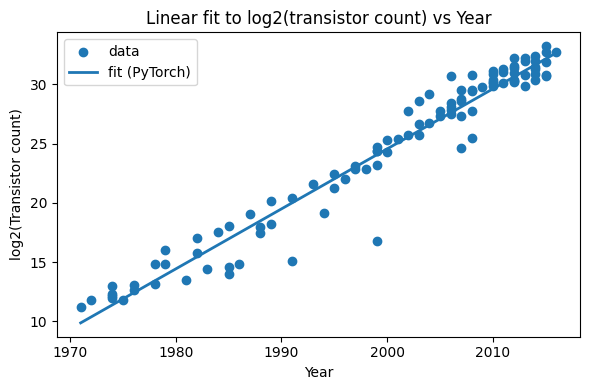

In [43]:
# Plot fit on log2 scale
fig2, ax2 = plt.subplots(figsize=(6,4))
ax2.scatter(years, log2_counts, label='data')
ax2.plot(years, y_pred, label='fit (PyTorch)', linewidth=2)
ax2.set_xlabel("Year")
ax2.set_ylabel("log2(Transistor count)")
ax2.set_title("Linear fit to log2(transistor count) vs Year")
ax2.legend()
fig2_path = "moore_log2_fit.png"
fig2.tight_layout()
fig2.savefig(fig2_path)

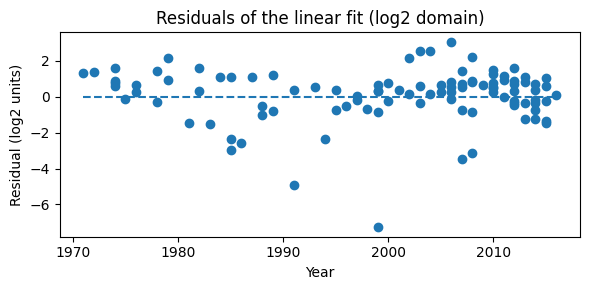

In [44]:
# Plot residuals
fig3, ax3 = plt.subplots(figsize=(6,3))
ax3.hlines(0, years.min(), years.max(), linestyle='--')
ax3.scatter(years, residuals)
ax3.set_xlabel("Year")
ax3.set_ylabel("Residual (log2 units)")
ax3.set_title("Residuals of the linear fit (log2 domain)")
fig3_path = "moore_residuals.png"
fig3.tight_layout()
fig3.savefig(fig3_path)

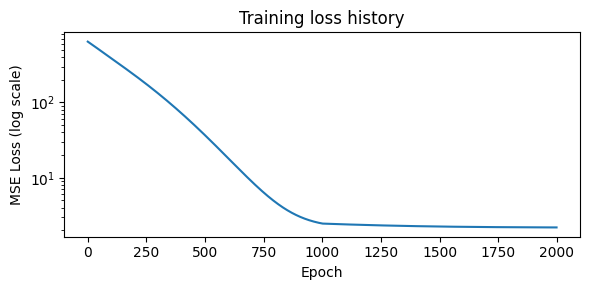

In [45]:
# Loss history plot
fig4, ax4 = plt.subplots(figsize=(6,3))
ax4.plot(loss_history)
ax4.set_yscale('log')
ax4.set_xlabel("Epoch")
ax4.set_ylabel("MSE Loss (log scale)")
ax4.set_title("Training loss history")
fig4_path = "moore_loss_history.png"
fig4.tight_layout()
fig4.savefig(fig4_path)


In [46]:
# Save results CSV
df_out = df2.copy()
df_out['log2_count'] = log2_counts
df_out['log2_pred'] = y_pred
df_out['residual_log2'] = residuals
out_csv = "moore_results_with_preds.csv"
df_out.to_csv(out_csv, index=False)

In [47]:
print("\nSaved outputs:")
print(fig1_path)
print(fig2_path)
print(fig3_path)
print(fig4_path)
print(out_csv)


Saved outputs:
moore_count_vs_year_log.png
moore_log2_fit.png
moore_residuals.png
moore_loss_history.png
moore_results_with_preds.csv


In [48]:
# Display the main fit plot inline
plt.figure(fig2.number)
plt.show()

<Figure size 640x480 with 0 Axes>